## 0. 세팅하기

### 기본환경

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import duckdb as dd
import dotenv
import json

In [2]:
import warnings
warnings.filterwarnings("ignore")

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
/bin/bash: line 1: fc-cache: command not found


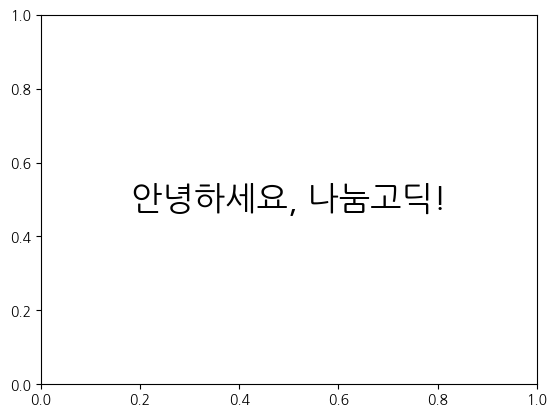

In [3]:

##########################################
### 한글이 깨지는 경우 아래 코드 실행하기 !!!###
##########################################
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트를 설치합니다.
!apt-get install -y fonts-nanum
!fc-cache -fv

# 설치된 나눔고딕 폰트를 matplotlib에 등록합니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'

# 폰트가 잘 설정되었는지 테스트합니다.
plt.text(0.5, 0.5, '안녕하세요, 나눔고딕!', ha='center', va='center', size=24)
plt.show()

In [4]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [5]:
# 현재 작업 디렉토리 출력
wd = os.getcwd()
wd

'/home/sprintda07/project4/final_project_team3'

In [6]:
# 절대 경로 (수정해서 사용)
JSON_KEY_PATH = "key/my-projectcodeit.json"

In [7]:
# DuckDB 연결
env_path = dotenv.find_dotenv()

dotenv.load_dotenv(
    dotenv_path=env_path,
    override=True
)

mem_con = dd.connect("mydb.duckdb")

HMAC_ID = os.getenv("HMAC_ID")
HMAC_PW = os.getenv("HMAC_PW")

secret_gcs = f"""
CREATE SECRET (
    TYPE GCS,
    KEY_ID '{HMAC_ID}',
    SECRET '{HMAC_PW}'
);
"""

mem_con.execute(secret_gcs)
mem_con.execute("FROM duckdb_secrets()").df()

,name,type,provider,persistent,storage,scope,secret_string
0,__default_gcs,gcs,config,False,memory,"[gcs://, gs://]",name=__default_gcs;type=gcs;provider=config;se...


### 데이터 불러오기

In [9]:
attendance_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [10]:
blockrecord_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_blockrecord.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [11]:
failpaymenthistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_failpaymenthistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [12]:
friendrequest_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_friendrequest.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [13]:
group_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_group.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [14]:
nearbyschool_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_nearbyschool.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [15]:
paymenthistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [70]:
pointhistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [17]:
school_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_school.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [18]:
timelinereport_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_timelinereport.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [19]:
contacts_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_user_contacts.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [17]:
userquestionrecord_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [21]:
userwithdraw_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userwithdraw.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [22]:
event_receipts_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_receipts.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [23]:
events_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/events.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [103]:
user_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_user.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [25]:
polls_question_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_question.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [26]:
polls_questionpiece_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionpiece.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [27]:
polls_questionreport_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionreport.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [28]:
polls_questionset_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionset.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [29]:
polls_usercandidate_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_usercandidate.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

# 2. 피쳐 엔지니어링

### 1) 투표 테이블: 투표기록 + 포인트 기록
userquestionrecord_df

In [8]:
userquestionrecord_df = mem_con.execute("""
    SELECT * FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet')
""").fetchdf()

print(userquestionrecord_df.head())
pointhistory_df = mem_con.execute("""
    SELECT * FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet')
""").fetchdf()

print(pointhistory_df.head())

       id status          created_at  chosen_user_id  question_id  user_id  \
0  771777      C 2023-04-28 12:27:49          849469          252   849436   
1  771800      C 2023-04-28 12:28:02          849446          244   849436   
2  771812      C 2023-04-28 12:28:09          849454          183   849436   
3  771828      C 2023-04-28 12:28:16          847375          101   849436   
4  771851      C 2023-04-28 12:28:26          849477          209   849436   

   question_piece_id  has_read answer_status   answer_updated_at  \
0             998458         0             N 2023-04-28 12:27:49   
1             998459         0             N 2023-04-28 12:28:02   
2             998460         1             N 2023-04-28 12:28:09   
3             998461         0             N 2023-04-28 12:28:16   
4             998462         1             N 2023-04-28 12:28:26   

   report_count  opened_times  
0             0             0  
1             0             0  
2             0           

In [9]:
len(userquestionrecord_df), len(pointhistory_df)

(1217558, 2338918)

# todo: 합산한거 없애고 
1. chosen user id에 머지
2. user id에 머지
각각 따로 gcs에 올리기

In [10]:
pointhistory_df = pointhistory_df.sort_values("created_at")
userquestionrecord_df = userquestionrecord_df.sort_values("created_at")

In [ ]:
# pointhistory_df를 user_id와 user_question_record_id로 그룹화하여, delta_point를 리스트화
updated_pointhistory_df = (
    pointhistory_df.groupby(["user_question_record_id", "user_id"])["delta_point"]
    .apply(list)
    .reset_index()
    .rename(columns={"user_id": "point_owner", "delta_point": "delta_points"})
)
updated_pointhistory_df

,user_question_record_id,point_owner,delta_points
0,771777.0,849436,[9]
1,771800.0,849436,[9]
2,771812.0,849436,[5]
3,771828.0,849436,[13]
4,771851.0,849436,[5]
...,...,...,...
2227067,161666462.0,855525,[14]
2227068,161666463.0,855525,[11]
2227069,161666463.0,855526,[11]
2227070,161666464.0,855525,[12]


In [ ]:
# join on user_id
merged_case1 = userquestionrecord_df.merge(
    updated_pointhistory_df,
    left_on=["id", "user_id"],
    right_on=["user_question_record_id", "point_owner"],
)

In [92]:
# join on chosen_user_id
merged_case2 = userquestionrecord_df.merge(
    updated_pointhistory_df,
    left_on=["id", "chosen_user_id"],
    right_on=["user_question_record_id", "point_owner"],
)

In [98]:
# 최종 데이터프레임 생성
df_merged = pd.concat([merged_case1, merged_case2], axis=0)
df_merged

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,user_question_record_id,point_owner,delta_points
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,771777.0,849436,[9]
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,771800.0,849436,[9]
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,771812.0,849436,[5]
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,771828.0,849436,[13]
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,771851.0,849436,[5]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011472,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,161666166.0,945560,[8]
1011473,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,161666461.0,850774,[5]
1011474,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,161666462.0,855509,[14]
1011475,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,161666463.0,855526,[11]


In [103]:
df_merged.iloc[0]

id                                      771777
status                                       C
created_at                 2023-04-28 12:27:49
chosen_user_id                          849469
question_id                                252
user_id                                 849436
question_piece_id                       998458
has_read                                     0
answer_status                                N
answer_updated_at          2023-04-28 12:27:49
report_count                                 0
opened_times                                 0
user_question_record_id               771777.0
point_owner                             849436
delta_points                               [9]
Name: 0, dtype: object

In [100]:
# DuckDB에 데이터프레임 저장
mem_con.execute("""
    COPY df_merged TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet' (FORMAT PARQUET);
""")

In [ ]:
# pandas로 GCS에 데이터 저장
# def write_data_to_gcs(df, JSON_KEY_PATH, DATASET_PATH, file_name):
#     df.to_parquet(
#         path=f'{DATASET_PATH}/{file_name}.parquet',
#         engine='pyarrow',
#         compression='gzip',
#         index=False,
#         storage_options={'token' : JSON_KEY_PATH}
#     )
# write_data_to_gcs(df_merged, JSON_KEY_PATH, "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes", "vote_point_df")

### 3. 추가 EDA

In [104]:
question_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [105]:
vote_point_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [106]:
event_info_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_info_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [107]:
user_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/user_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [108]:
paymenthistory_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

question_df

1. 어떤 질문에 투표/스킵이 가장 많은가?

In [13]:
question_stats = (
    question_df
    .groupby("question_text")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    .reset_index()
)
print("=== 질문별 투표통계 (Top 10) ===")
print(question_stats.sort_values("vote_count", ascending=False).head(10))


print("\n\n=== 질문별 스킵통계 (Top 10) ===")
print(question_stats.sort_values("skip_count", ascending=False).head(10))

=== 질문별 투표통계 (Top 10) ===
                      question_text  vote_count  skip_count  total_count
87                             vote      9703.0         9.0        10169
26             2세가 가장 귀여울 것 같은 사람은?      2174.0         3.0         2228
500                 같이 캠핑가고 싶은 사람은?      2123.0         1.0         2169
1256              라면 잘 끓일 것 같은 사람은?      2115.0         1.0         2157
3270  처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?      1998.0         2.0         2030
1464          모든 사람과 잘 지낼 것 같은 사람은?      1987.0         1.0         2021
3358       축제에서 공연을 제일 잘 할거 같은 사람은?      1985.0         1.0         2017
2297    앞으로의 인생을 가장 재미있게 살것 같은 사람은?      1975.0         1.0         2009
1612         반려동물과 가장 잘 지낼거 같은 사람은?      1958.0         2.0         1985
129                가장 깔끔할 것 같은 친구는?      1957.0         1.0         1998


=== 질문별 스킵통계 (Top 10) ===
                      question_text  vote_count  skip_count  total_count
87                             vote      9703.0         9.0        101

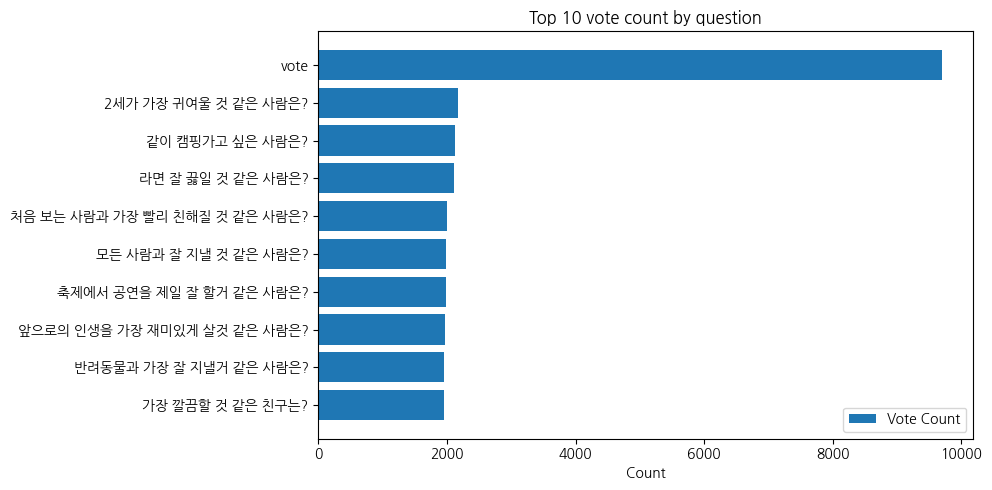

In [14]:
plt.figure(figsize=(10, 5))
_question_stats = question_stats.sort_values("vote_count", ascending=False).head(10)
plt.barh(_question_stats["question_text"], _question_stats["vote_count"], label="Vote Count")
plt.title("Top 10 vote count by question")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

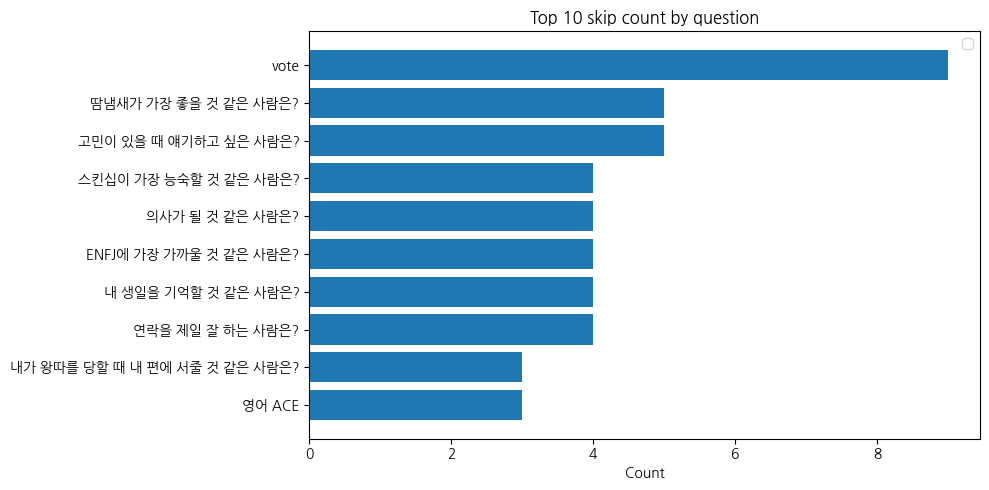

In [15]:
plt.figure(figsize=(10, 5))
_question_stats = question_stats.sort_values("skip_count", ascending=False).head(10)
plt.barh(_question_stats["question_text"], _question_stats["skip_count"])
plt.title("Top 10 skip count by question")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. 어느 유저가 투표/스킵이 가장 많은가?

In [16]:
user_stats = (
    question_df
    .groupby("user_id")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    
    .reset_index()
)
print("=== 유저별 투표 통계 (Top 10) ===")
print(user_stats.sort_values("vote_count", ascending=False).head(10))


print("\\n\n=== 유저별 스킵 통계 (Top 10) ===")
print(user_stats.sort_values("skip_count", ascending=False).head(10))

=== 유저별 투표 통계 (Top 10) ===
      user_id  vote_count  skip_count  total_count
20     849103      2786.0         0.0         2796
808    876509      1708.0         0.0         1718
277    856042      1701.0         0.0         1711
3312  1213990      1695.0         0.0         1705
2879  1159163      1656.0         0.0         1666
2227  1058255      1544.0         0.0         1554
3231  1206529      1544.0         0.0         1554
1865   952220      1527.0         0.0         1537
2984  1170559      1513.0         0.0         1523
3469  1236004      1482.0         0.0         1492
\n
=== 유저별 스킵 통계 (Top 10) ===
      user_id  vote_count  skip_count  total_count
3819  1289797        10.0         9.0           10
2643  1138345       261.0         9.0          262
3292  1211694        10.0         9.0           10
1463   888374       207.0         9.0          208
1797   931987       135.0         9.0          136
4178  1381024        22.0         8.0           24
3958  1325806         8.0

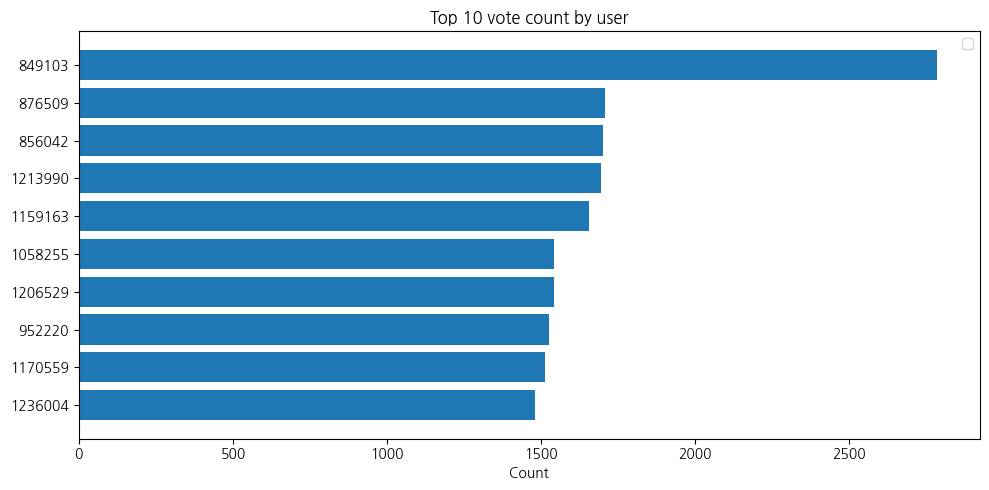

In [17]:
plt.figure(figsize=(10, 5))
_user_stats = user_stats.sort_values("vote_count", ascending=False).head(10)
vote_merged_df = user_df.merge(_user_stats, on="user_id", how="right")
_user_stats["user_id"] = _user_stats["user_id"].astype(str)
plt.barh(_user_stats["user_id"], _user_stats["vote_count"])
plt.title("Top 10 vote count by user")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

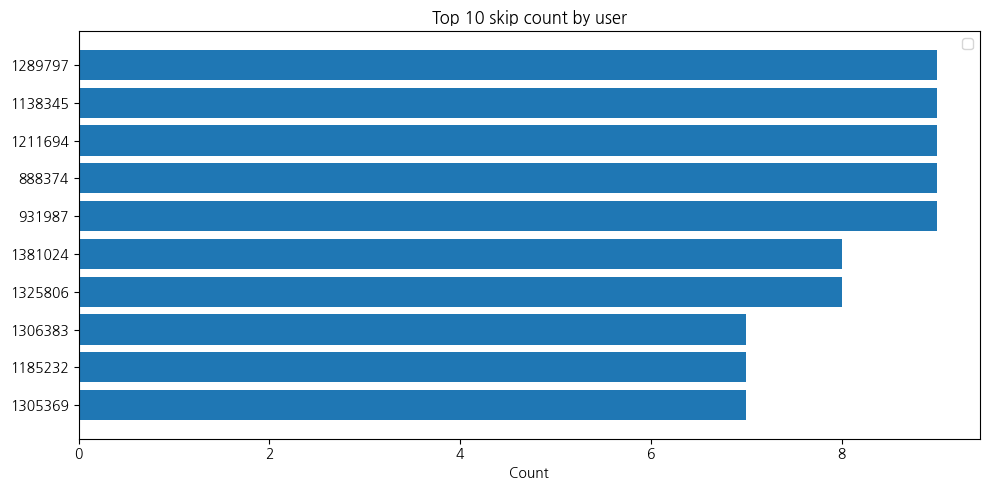

In [18]:
plt.figure(figsize=(10, 5))
_user_stats = user_stats.sort_values("skip_count", ascending=False).head(10)
skip_merged_df = user_df.merge(_user_stats, on="user_id", how="right")
_user_stats["user_id"] = _user_stats["user_id"].astype(str)
plt.barh(_user_stats["user_id"], _user_stats["skip_count"])
plt.title("Top 10 skip count by user")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
vote_merged_df.gender.value_counts()

gender
F    7
M    3
Name: count, dtype: int64

In [20]:
vote_merged_df.school_type.value_counts()

school_type
H    8
M    2
Name: count, dtype: int64

In [21]:
vote_merged_df["attendance_date_list"] = vote_merged_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

vote_merged_df["n_attendance_dates"] = vote_merged_df["attendance_date_list"].apply(lambda x: len(x))
vote_merged_df["n_attendance_dates"].describe()

count    10.000000
mean     18.100000
std      20.534253
min       0.000000
25%       5.000000
50%      11.000000
75%      25.000000
max      69.000000
Name: n_attendance_dates, dtype: float64

In [22]:
vote_merged_df["friend_id_list"] = vote_merged_df["friend_id_list"].apply(json.loads)
vote_merged_df["n_friends"] = vote_merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
vote_merged_df

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,vote_count,skip_count,total_count,n_attendance_dates,n_friends
0,849103,0,0,F,41607,"[857602, 857603, 858120, 860682, 839179, 84840...",0,2023-04-27 13:45:23.532923,[],[],N,0,0,3,0,3833.0,99303.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,2.0,271.0,충청남도 천안시 서북구,491.0,H,2786.0,0.0,2796,69,128
1,876509,0,0,F,1376,"[886913, 879875, 871940, 875780, 884230, 88320...",1,2023-05-03 13:09:50.190280,[],[875705],N,0,0,0,0,10153.0,331598.0,"[2023-06-18, 2023-06-19, 2023-06-20, 2023-06-2...",2.0,13.0,4516.0,경기도 화성시,507.0,H,1708.0,0.0,1718,29,60
2,856042,0,0,F,5887,"[864897, 855694, 874002, 861205, 863392, 86595...",1,2023-04-29 23:52:14.010394,[],[],N,0,2,4,35,3833.0,125871.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-06-0...",1.0,2.0,271.0,충청남도 천안시 서북구,491.0,H,1701.0,0.0,1711,5,51
3,1213990,0,0,M,3883,"[1185408, 1206529, 1220102, 1217035, 1206668, ...",1,2023-05-13 11:25:06.724268,[],[],N,0,0,0,12,33879.0,25001.0,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1.0,10.0,1719.0,울산광역시 울주군,550.0,H,1695.0,0.0,1705,9,29
4,1159163,0,0,F,11021,"[1217921, 1158530, 1241988, 1122820, 1142661, ...",1,2023-05-12 05:51:30.378418,[],[],N,0,1,0,2,45939.0,152020.0,"[2023-05-29, 2023-05-30, 2023-05-31, 2023-06-0...",2.0,12.0,5491.0,경기도 광주시,486.0,H,1656.0,0.0,1666,13,63
5,1058255,0,0,F,15723,"[1432576, 1159808, 1242882, 1138054, 1448327, ...",1,2023-05-09 14:15:04.082002,[],[],N,0,2,0,3,36400.0,NaN,[],2.0,9.0,5520.0,경기도 광명시,500.0,M,1544.0,0.0,1554,0,75
6,1206529,0,0,F,2847,"[955521, 1204866, 1220102, 1217163, 1206668, 1...",1,2023-05-13 09:04:54.133308,[],[],N,0,1,0,77,33879.0,213862.0,"[2023-05-29, 2023-05-30, 2023-06-01, 2023-06-0...",1.0,10.0,1719.0,울산광역시 울주군,550.0,H,1544.0,0.0,1554,5,52
7,952220,0,0,M,21998,"[886787, 886180, 886245, 888453, 905351, 89616...",1,2023-05-07 08:21:12.387888,[],[],N,0,0,0,0,6875.0,9702.0,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,8.0,352.0,충청남도 아산시,491.0,H,1527.0,0.0,1537,26,14
8,1170559,0,0,M,11908,"[1161604, 959620, 1159697, 1210259, 1100179, 9...",1,2023-05-12 11:03:39.049790,[],[],N,0,0,0,0,27495.0,39253.0,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",3.0,10.0,1478.0,인천광역시 서구,489.0,M,1513.0,0.0,1523,22,28
9,1236004,0,0,F,7775,"[1227266, 1275523, 1257737, 1354890, 1256460, ...",1,2023-05-13 16:03:41.457384,[],[],N,0,0,0,3,55673.0,58450.0,"[2023-05-27, 2023-05-29, 2023-06-18]",2.0,6.0,1719.0,울산광역시 울주군,550.0,H,1482.0,0.0,1492,3,46


In [23]:
skip_merged_df.gender.value_counts()

gender
F    9
M    1
Name: count, dtype: int64

In [24]:
skip_merged_df.school_type.value_counts()

school_type
H    9
M    1
Name: count, dtype: int64

In [25]:
skip_merged_df["attendance_date_list"] = skip_merged_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

skip_merged_df["n_attendance_dates"] = skip_merged_df["attendance_date_list"].apply(lambda x: len(x))
skip_merged_df["n_attendance_dates"].describe()

count    10.000000
mean      2.300000
std       6.929005
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      22.000000
Name: n_attendance_dates, dtype: float64

In [26]:
skip_merged_df["friend_id_list"] = skip_merged_df["friend_id_list"].apply(json.loads)
skip_merged_df["n_friends"] = skip_merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
skip_merged_df

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,vote_count,skip_count,total_count,n_attendance_dates,n_friends
0,1289797,0,0,F,903,"[927882, 1001610, 1077653, 923933, 913959, 924...",1,2023-05-15 11:51:29.487137,[],[],N,0,1,0,28,17950.0,NaN,[],2.0,2.0,1478.0,인천광역시 서구,489.0,M,10.0,9.0,10,0,50
1,1138345,0,0,F,6923,"[1308691, 1154585, 1274398, 1165346, 1147938, ...",1,2023-05-11 13:53:05.181784,[],[],N,0,1,0,335,46796.0,74241.0,[2023-05-28],2.0,2.0,5491.0,경기도 광주시,486.0,H,261.0,9.0,262,1,82
2,1211694,0,0,M,5620,"[1217928, 1210507, 1214735, 1207322, 1205405, ...",0,2023-05-13 10:49:21.077194,[],[1208640],N,0,1,0,221,44628.0,NaN,[],1.0,4.0,1719.0,울산광역시 울주군,550.0,H,10.0,9.0,10,0,61
3,888374,0,0,F,2468,"[885000, 860304, 888212, 888597, 881301, 88631...",1,2023-05-05 14:40:08.902152,[],[],N,0,1,0,48,12277.0,NaN,[],1.0,13.0,352.0,충청남도 아산시,491.0,H,207.0,9.0,208,0,27
4,931987,0,0,F,4574,"[886274, 887299, 883202, 883737, 849436, 88477...",1,2023-05-06 22:59:43.421026,[],[],N,0,1,0,196,12015.0,NaN,[],2.0,3.0,352.0,충청남도 아산시,491.0,H,135.0,9.0,136,0,78
5,1381024,0,0,F,68,"[968590, 1131675, 1144475, 1161757, 1277854, 1...",0,2023-05-19 07:35:44.413861,[],[],N,0,1,0,4,24762.0,NaN,[],1.0,12.0,5372.0,경기도 남양주시,505.0,H,22.0,8.0,24,0,37
6,1325806,0,0,F,254,"[1269125, 1165894, 1104234, 1091211, 1097932, ...",1,2023-05-16 12:48:41.722364,[],[],N,0,1,0,37,42042.0,NaN,[],2.0,6.0,5372.0,경기도 남양주시,505.0,H,8.0,8.0,10,0,37
7,1306383,0,0,F,2686,"[1117193, 1052425, 860173, 891669, 1368725, 12...",1,2023-05-16 04:05:33.541755,[],[],N,0,0,0,0,11104.0,99535.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,12.0,5491.0,경기도 광주시,486.0,H,212.0,7.0,214,22,29
8,1185232,0,0,F,1426,"[1187589, 1205269, 1202464, 1199401, 1183660, ...",0,2023-05-12 15:05:57.057229,[],"[1160250, 1198505, 1201680]",N,0,1,0,1,50815.0,NaN,[],3.0,2.0,5491.0,경기도 광주시,486.0,H,316.0,7.0,319,0,29
9,1305369,0,0,F,2606,"[1298438, 1354890, 1238029, 973584, 1277972, 1...",1,2023-05-16 03:22:04.118364,[],[],N,0,1,0,171,55673.0,NaN,[],2.0,6.0,1719.0,울산광역시 울주군,550.0,H,100.0,7.0,102,0,33


In [27]:
skip_merged_df["vote_count"].describe()

count     10.000000
mean     128.100000
std      115.780875
min        8.000000
25%       13.000000
50%      117.500000
75%      210.750000
max      316.000000
Name: vote_count, dtype: float64

3. 어느 시간대에 투표가 가장 활발한가?

In [28]:
question_df["hour"] = pd.to_datetime(question_df["created_at_set"]).dt.hour

time_stats = (
    question_df
    .groupby("hour")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    .reset_index()
    
)
print("=== 시간대별 투표 통계 ===")
print(time_stats.sort_values("vote_count", ascending=False).head(10))

print("\n\n=== 시간대별 스킵 통계 ===")
print(time_stats.sort_values("skip_count", ascending=False).head(10))

=== 시간대별 투표 통계 ===
    hour  vote_count  skip_count  total_count
13    13    100194.0       122.0       104844
14    14     98339.0        86.0       102441
12    12     87884.0       111.0        91306
15    15     80773.0       113.0        84721
11    11     79125.0        93.0        82194
10    10     72312.0        64.0        74887
9      9     71597.0        54.0        74497
8      8     71463.0        74.0        74138
7      7     62424.0        45.0        64497
6      6     54960.0        48.0        57001


=== 시간대별 스킵 통계 ===
    hour  vote_count  skip_count  total_count
13    13    100194.0       122.0       104844
15    15     80773.0       113.0        84721
12    12     87884.0       111.0        91306
11    11     79125.0        93.0        82194
14    14     98339.0        86.0       102441
8      8     71463.0        74.0        74138
10    10     72312.0        64.0        74887
9      9     71597.0        54.0        74497
6      6     54960.0        48.0        

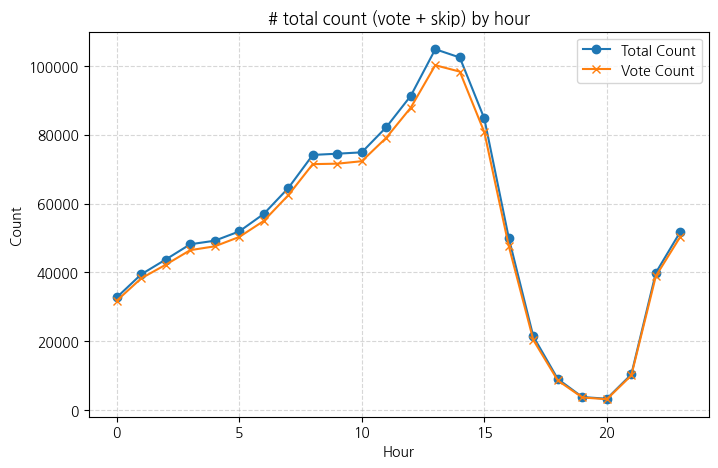

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(time_stats["hour"], time_stats["total_count"], marker="o", label="Total Count")
plt.plot(time_stats["hour"], time_stats["vote_count"], marker="x", label="Vote Count")
plt.title("# total count (vote + skip) by hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

vote_point_df

1. 어떤 질문에 포인트 사용량이 많은가?

In [161]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("delta_point", "sum"))
    .sort_values("total_point", ascending=False)
).head(10)
print("Top 10 포인트 사용 질문")
print(question_point_usage)

Top 10 포인트 사용 질문
     question_id  total_point
112          211      25188.0
207          306      25170.0
201          300      24699.0
167          266      24607.0
202          301      24595.0
170          269      24096.0
20           119      24023.0
71           170      23797.0
107          206      23723.0
159          258      23512.0


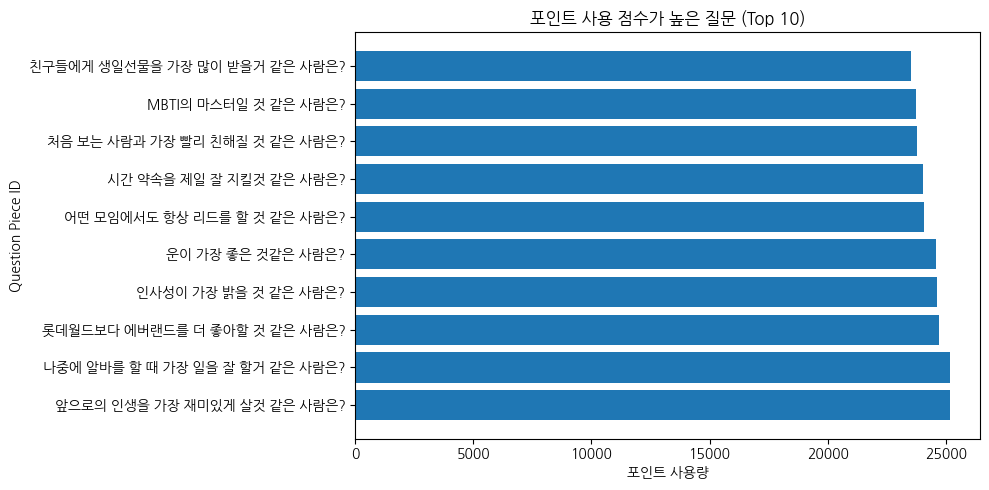

In [162]:
merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 사용 점수가 높은 질문 (Top 10)")
plt.ylabel("Question Piece ID")
plt.xlabel("포인트 사용량")
plt.tight_layout()
plt.show()

Top 10 포인트 사용 질문
     question_id  total_point
71           170         1996
191          290         1986
70           169         1984
112          211         1974
211          310         1956
87           186         1951
3            102         1946
145          244         1946
210          309         1939
53           152         1933


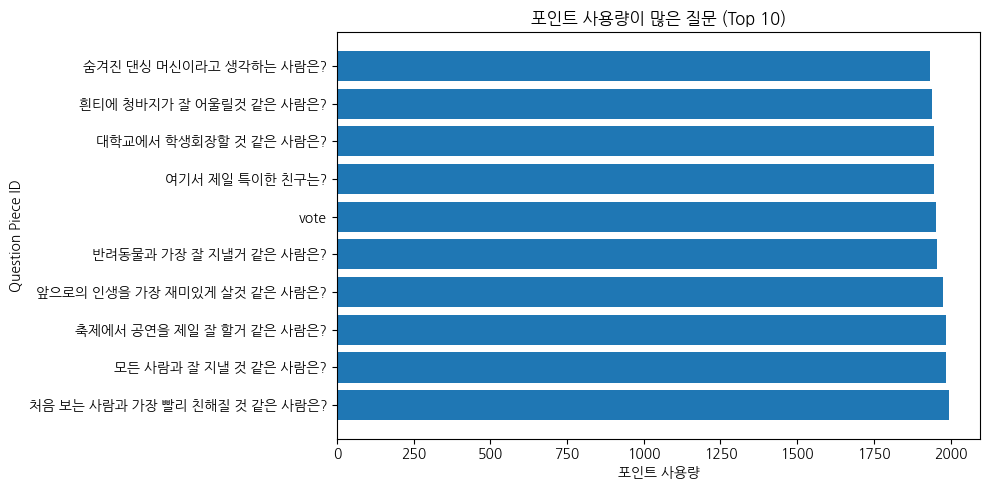

In [163]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("delta_point", "count"))
    .sort_values("total_point", ascending=False)
).head(10)
print("Top 10 포인트 사용 질문")
print(question_point_usage)

merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 사용량이 많은 질문 (Top 10)")
plt.ylabel("Question Piece ID")
plt.xlabel("포인트 사용량")
plt.tight_layout()
plt.show()

In [164]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("delta_point", "count"))
    .sort_values("total_point", ascending=True)
).head(10)
print("Bottom 10 포인트 사용 질문")
print(question_point_usage)

Bottom 10 포인트 사용 질문
      question_id  total_point
4603         4876            1
4539         4796            1
4540         4797            1
4334         4542            1
4333         4541            1
4331         4536            1
4544         4804            1
4096         4226            1
4546         4807            1
4330         4535            1


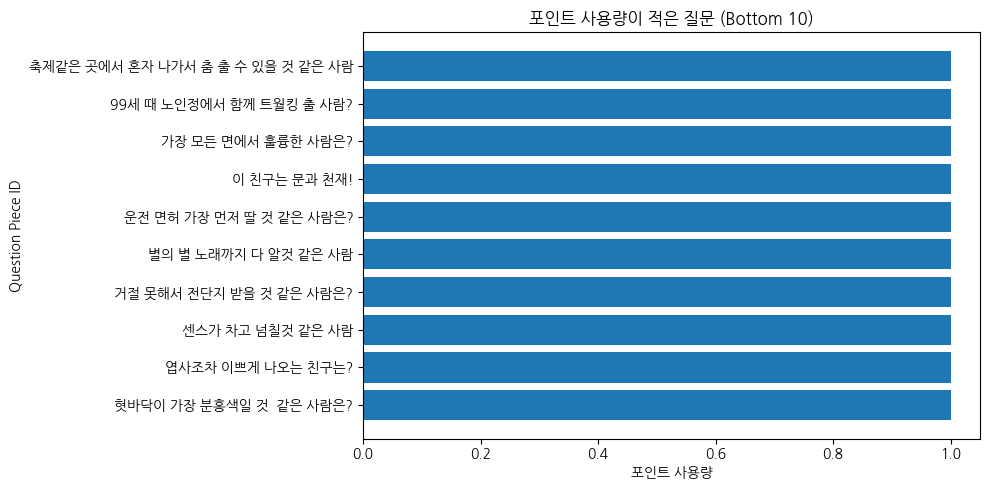

In [165]:
merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 사용량이 적은 질문 (Bottom 10)")
plt.ylabel("Question Piece ID")
plt.xlabel("포인트 사용량")
plt.tight_layout()
plt.show()

2. 어떤 유저가 선택을 많이 받는가?

In [55]:
user_selected = (
    vote_point_df
    .groupby("chosen_user_id", as_index=False)
    .size()
    .rename(columns={"size": "chosen_count"})
    .sort_values("chosen_count", ascending=False)
)
print("Top 10 선택 많이 받은 유저")
print(user_selected.head(10))

Top 10 선택 많이 받은 유저
       chosen_user_id  chosen_count
6000           913265          1239
10965         1206668          1054
13112         1402487          1049
9481          1122686          1042
7781           994573           997
8097          1017281           997
9624          1132932           993
2609           873259           971
10989         1207784           948
8098          1017447           917


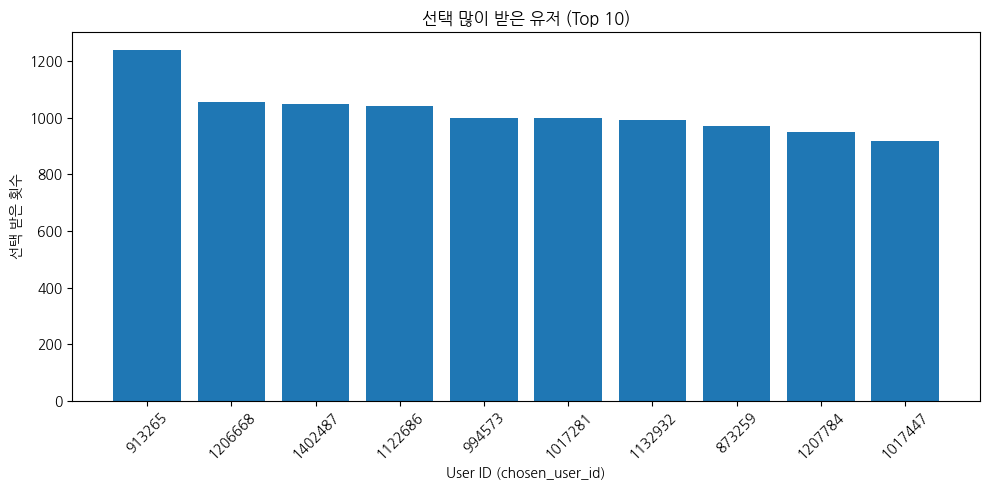

In [56]:
plt.figure(figsize=(10, 5))
plt.bar(user_selected["chosen_user_id"].astype(str).head(10),
        user_selected["chosen_count"].head(10))
plt.title("선택 많이 받은 유저 (Top 10)")
plt.xlabel("User ID (chosen_user_id)")
plt.ylabel("선택 받은 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
merged_df = user_selected.head(10).merge(user_df, left_on="chosen_user_id", right_on="user_id", how="left")
merged_df

,chosen_user_id,chosen_count,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
0,913265,1239,913265,0,0,M,5257,"[925184, 1103885, 1110033, 1036306, 946196, 15...",1,2023-05-06 12:47:33.544102,[],[],N,0,1,0,1258,17929.0,51551.0,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",2.0,11.0,1478.0,인천광역시 서구,489.0,M
1,1206668,1054,1206668,0,0,M,1240,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",1,2023-05-13 09:08:04.416313,[1209696],"[1210417, 1211694, 1187305, 1288492]",N,0,1,0,775,33879.0,NaN,None,1.0,10.0,1719.0,울산광역시 울주군,550.0,H
2,1402487,1049,1402487,0,0,M,3481,"[1402371, 1419804, 1403421, 1402919, 1406521, ...",1,2023-05-20 11:49:26.073098,[],[],N,0,0,0,893,68957.0,91963.0,"[""2023-05-28"", ""2023-05-29"", ""2023-05-30""]",3.0,4.0,4426.0,경상남도 거제시,483.0,H
3,1122686,1042,1122686,0,0,M,5427,"[1432576, 1133058, 1205259, 1089040, 1043473, ...",1,2023-05-11 08:08:47.657849,[],[],N,0,1,0,999,29558.0,NaN,None,2.0,10.0,5520.0,경기도 광명시,500.0,M
4,994573,997,994573,0,0,F,177,"[1432576, 1189890, 1427466, 964107, 1205259, 9...",0,2023-05-08 07:11:58.076137,[],[],N,0,0,0,885,31383.0,NaN,None,2.0,4.0,5520.0,경기도 광명시,500.0,M
5,1017281,997,1017281,0,0,F,3570,"[1038861, 943631, 1172496, 1224723, 1018394, 1...",0,2023-05-08 14:20:46.163313,[],[],N,0,1,0,1004,22968.0,NaN,None,3.0,7.0,5520.0,경기도 광명시,500.0,M
6,1132932,993,1132932,0,0,F,2916,"[1134602, 1205259, 1043473, 1430036, 1044507, ...",1,2023-05-11 12:39:39.339638,[],[],N,0,1,0,957,23119.0,NaN,None,2.0,12.0,5520.0,경기도 광명시,500.0,M
7,873259,971,873259,0,0,F,2177,"[871940, 941573, 876549, 884230, 883208, 87757...",0,2023-05-02 23:29:42.843284,[],[],N,0,1,0,943,9505.0,NaN,None,2.0,4.0,4516.0,경기도 화성시,507.0,H
8,1207784,948,1207784,0,0,M,882,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",0,2023-05-13 09:35:18.591577,[],[1180034],N,4,1,0,709,49478.0,NaN,None,1.0,2.0,1719.0,울산광역시 울주군,550.0,H
9,1017447,917,1017447,0,0,F,1707,"[947719, 1039882, 943631, 1172496, 1036834, 10...",1,2023-05-08 14:22:41.181466,[],[],N,0,0,0,5,34259.0,333074.0,"[""2023-06-22"", ""2023-08-02""]",3.0,12.0,5520.0,경기도 광명시,500.0,M


In [59]:
merged_df.gender.value_counts()

gender
M    5
F    5
Name: count, dtype: int64

In [60]:
merged_df.school_type.value_counts()

school_type
M    6
H    4
Name: count, dtype: int64

In [61]:
merged_df["friend_id_list"] = merged_df["friend_id_list"].apply(json.loads)
merged_df["n_friends"] = merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
merged_df

,chosen_user_id,chosen_count,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,n_friends
0,913265,1239,913265,0,0,M,5257,"[925184, 1103885, 1110033, 1036306, 946196, 15...",1,2023-05-06 12:47:33.544102,[],[],N,0,1,0,1258,17929.0,51551.0,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",2.0,11.0,1478.0,인천광역시 서구,489.0,M,205
1,1206668,1054,1206668,0,0,M,1240,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",1,2023-05-13 09:08:04.416313,[1209696],"[1210417, 1211694, 1187305, 1288492]",N,0,1,0,775,33879.0,NaN,None,1.0,10.0,1719.0,울산광역시 울주군,550.0,H,214
2,1402487,1049,1402487,0,0,M,3481,"[1402371, 1419804, 1403421, 1402919, 1406521, ...",1,2023-05-20 11:49:26.073098,[],[],N,0,0,0,893,68957.0,91963.0,"[""2023-05-28"", ""2023-05-29"", ""2023-05-30""]",3.0,4.0,4426.0,경상남도 거제시,483.0,H,94
3,1122686,1042,1122686,0,0,M,5427,"[1432576, 1133058, 1205259, 1089040, 1043473, ...",1,2023-05-11 08:08:47.657849,[],[],N,0,1,0,999,29558.0,NaN,None,2.0,10.0,5520.0,경기도 광명시,500.0,M,168
4,994573,997,994573,0,0,F,177,"[1432576, 1189890, 1427466, 964107, 1205259, 9...",0,2023-05-08 07:11:58.076137,[],[],N,0,0,0,885,31383.0,NaN,None,2.0,4.0,5520.0,경기도 광명시,500.0,M,192
5,1017281,997,1017281,0,0,F,3570,"[1038861, 943631, 1172496, 1224723, 1018394, 1...",0,2023-05-08 14:20:46.163313,[],[],N,0,1,0,1004,22968.0,NaN,None,3.0,7.0,5520.0,경기도 광명시,500.0,M,98
6,1132932,993,1132932,0,0,F,2916,"[1134602, 1205259, 1043473, 1430036, 1044507, ...",1,2023-05-11 12:39:39.339638,[],[],N,0,1,0,957,23119.0,NaN,None,2.0,12.0,5520.0,경기도 광명시,500.0,M,119
7,873259,971,873259,0,0,F,2177,"[871940, 941573, 876549, 884230, 883208, 87757...",0,2023-05-02 23:29:42.843284,[],[],N,0,1,0,943,9505.0,NaN,None,2.0,4.0,4516.0,경기도 화성시,507.0,H,149
8,1207784,948,1207784,0,0,M,882,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",0,2023-05-13 09:35:18.591577,[],[1180034],N,4,1,0,709,49478.0,NaN,None,1.0,2.0,1719.0,울산광역시 울주군,550.0,H,179
9,1017447,917,1017447,0,0,F,1707,"[947719, 1039882, 943631, 1172496, 1036834, 10...",1,2023-05-08 14:22:41.181466,[],[],N,0,0,0,5,34259.0,333074.0,"[""2023-06-22"", ""2023-08-02""]",3.0,12.0,5520.0,경기도 광명시,500.0,M,101


3. 선택을 많이 받은 유저가 투표도 활발하게 하는가?

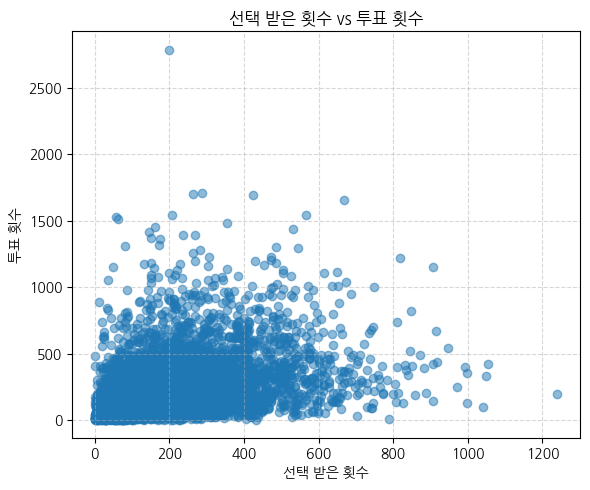

선택 받은 횟수와 투표 횟수 간 상관계수: 0.35


In [62]:
user_voting = (
    vote_point_df
    .groupby("user_id", as_index=False)
    .size()
    .rename(columns={"size": "vote_count"})
    .sort_values("vote_count", ascending=False)
)

merged_selection_vote = (
    user_selected.merge(user_voting,
                        left_on="chosen_user_id",
                        right_on="user_id",
                        how="inner")
)
plt.figure(figsize=(6, 5))
plt.scatter(merged_selection_vote["chosen_count"],
            merged_selection_vote["vote_count"],
            alpha=0.5)
plt.title("선택 받은 횟수 vs 투표 횟수")
plt.xlabel("선택 받은 횟수")
plt.ylabel("투표 횟수")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

correlation = merged_selection_vote[["chosen_count", "vote_count"]].corr().iloc[0, 1]
print(f"선택 받은 횟수와 투표 횟수 간 상관계수: {correlation:.2f}")

4. 어느 시간대에 포인트 사용량이 많은가?

시간대별 포인트 사용량
    hour  delta_point
23    23     536140.0
12    12     513951.0
13    13     513119.0
14    14     498552.0
11    11     460799.0
10    10     444140.0
8      8     440316.0
9      9     434286.0
7      7     404970.0
5      5     403923.0
6      6     386908.0
22    22     369699.0
15    15     366862.0
3      3     366318.0
4      4     349139.0
2      2     342544.0
1      1     328938.0
0      0     304632.0
16    16     264924.0
17    17     145175.0
21    21     103194.0
18    18      67233.0
20    20      30759.0
19    19      27896.0


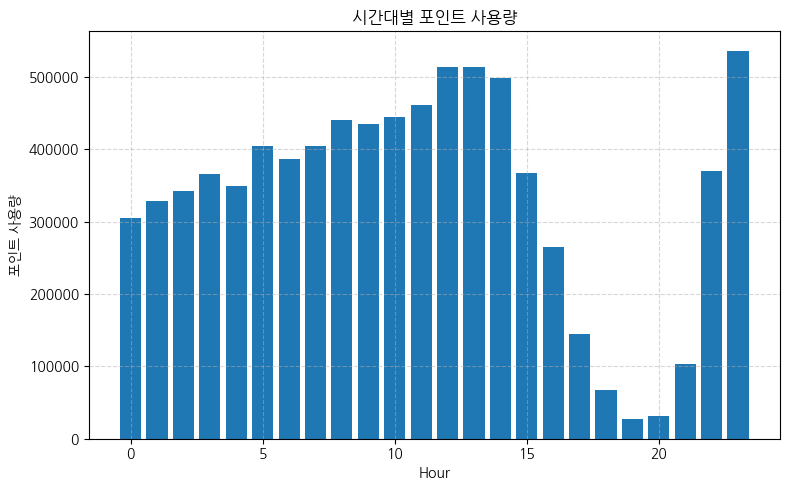

In [67]:
vote_point_df["hour"] = pd.to_datetime(vote_point_df["created_at_point"]).dt.hour
point_by_hour = (
    vote_point_df.groupby("hour", as_index=False)["delta_point"].sum()
    .sort_values("delta_point", ascending=False)
)
print("시간대별 포인트 사용량")
print(point_by_hour)

plt.figure(figsize=(8, 5))
plt.bar(point_by_hour["hour"], point_by_hour["delta_point"])
plt.title("시간대별 포인트 사용량")
plt.xlabel("Hour")
plt.ylabel("포인트 사용량")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

5. 유저 세그맨트

포인트 사용자 vs 미사용자 수
segment
point_user        3923
non_point_user     926
Name: count, dtype: int64


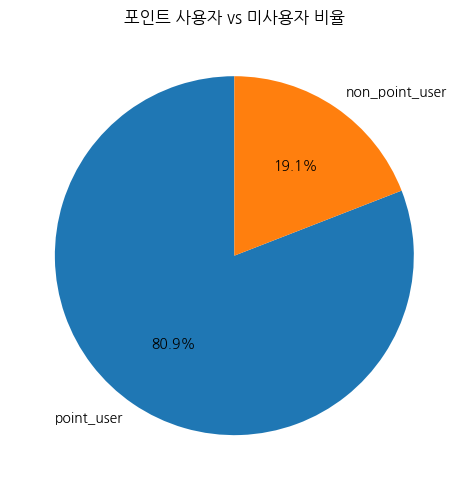

In [69]:
user_point_usage = (
    vote_point_df.groupby("user_id", as_index=False)["delta_point"].sum()
)
user_point_usage["segment"] = user_point_usage["delta_point"].apply(
    lambda x: "point_user" if x > 0 else "non_point_user"
)

segment_summary = user_point_usage["segment"].value_counts()
print("포인트 사용자 vs 미사용자 수")
print(segment_summary)

plt.figure(figsize=(5, 5))
plt.pie(segment_summary, labels=segment_summary.index, autopct="%1.1f%%",
        startangle=90)
plt.title("포인트 사용자 vs 미사용자 비율")
plt.tight_layout()
plt.show()

event_info_df

1. 어느 이벤트가 가장 많이 참여 되었는가

=== 이벤트별 참여 Top 10 ===
   event_id           title  plus_point_event  participation_count
0         1   코드잇 은행 가입 이벤트               500                  252
1         2  코드잇 멤버십 가입 이벤트              1000                   37
2         3   예고 영상 기대평 이벤트               500                   20


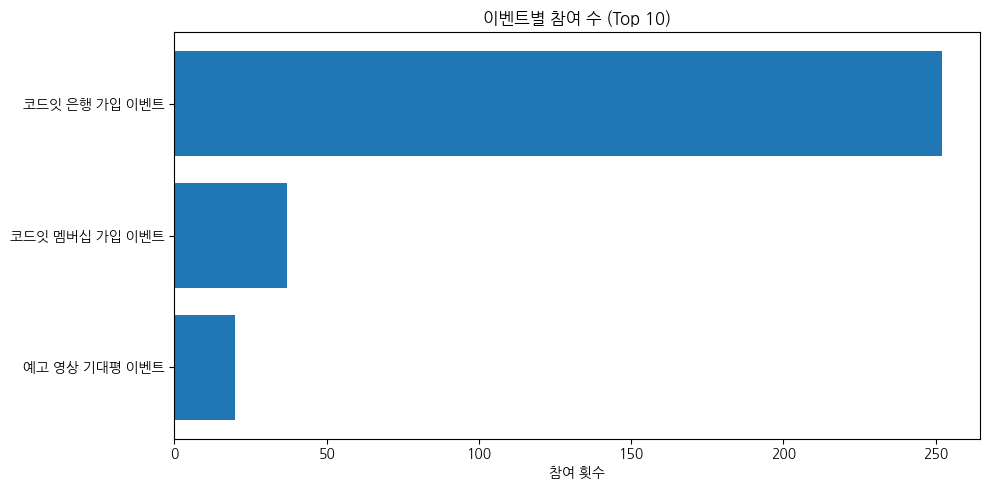

In [75]:
event_participation = (
    event_info_df
    .groupby(["event_id", "title", "plus_point_event"], as_index=False)
    .size()
    .rename(columns={"size": "participation_count"})
    .sort_values("participation_count", ascending=False)
)
print("=== 이벤트별 참여 Top 10 ===")
print(event_participation.head(10))

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(event_participation["title"].head(10),
         event_participation["participation_count"].head(10))
plt.title("이벤트별 참여 수 (Top 10)")
plt.xlabel("참여 횟수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. 어느 유저가 이벤트에 많이 참여하나

=== 유저별 이벤트 참여 Top 10 ===
     user_id  participation_count
297  1577954                    2
0     837836                    1
211  1290597                    1
209  1286727                    1
208  1275883                    1
207  1272917                    1
206  1268928                    1
205  1265520                    1
204  1256318                    1
203  1248265                    1


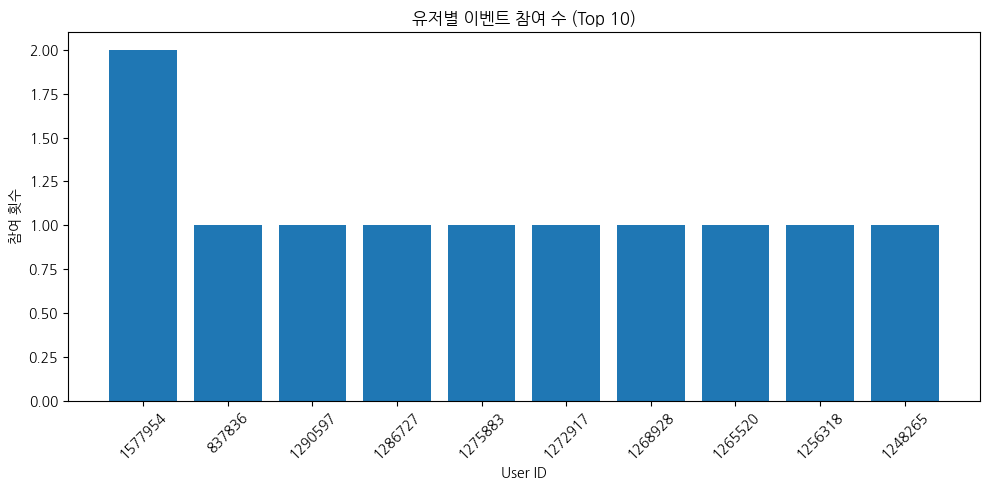

In [76]:
user_participation = (
    event_info_df
    .groupby("user_id", as_index=False)
    .size()
    .rename(columns={"size": "participation_count"})
    .sort_values("participation_count", ascending=False)
)
print("=== 유저별 이벤트 참여 Top 10 ===")
print(user_participation.head(10))

plt.figure(figsize=(10, 5))
plt.bar(user_participation["user_id"].astype(str).head(10),
        user_participation["participation_count"].head(10))
plt.title("유저별 이벤트 참여 수 (Top 10)")
plt.xlabel("User ID")
plt.ylabel("참여 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
user_df[user_df["user_id"].eq(1577954)]

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
671688,1577954,0,0,F,99212,"[838785, 982531, 882567, 879496, 838541, 83649...",1,2023-07-09 18:07:04.204081,[],[],N,71,21,1801,11,1.0,357483.0,"[""2023-10-20""]",1.0,1.0,1.0,None,NaN,None


3. 이벤트 참여한 유저들은 투표/포인트 사용량이 높은가

=== 유저 행동 지표 상관계수 ===
                              event_participation_count  total_point_used  \
event_participation_count                      1.000000         -0.237783   
total_point_used                              -0.237783          1.000000   
question_participation_count                  -0.252445          0.653303   

                              question_participation_count  
event_participation_count                        -0.252445  
total_point_used                                  0.653303  
question_participation_count                      1.000000  


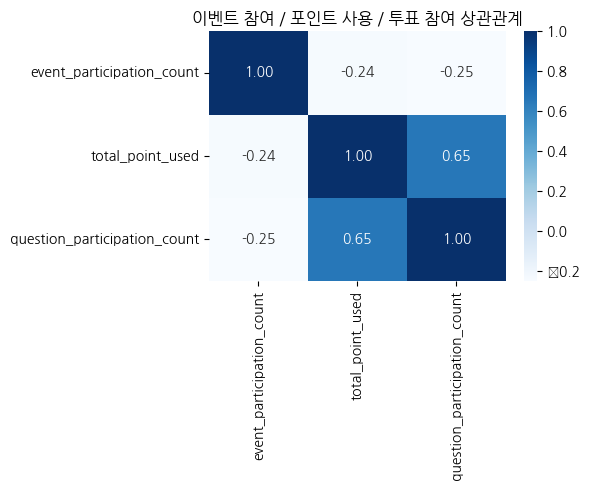

In [92]:
event_summary = event_info_df.groupby("user_id").size().reset_index(name="event_participation_count")

vote_point_summary = vote_point_df.groupby("user_id_point")["delta_point"].sum().reset_index()
vote_point_summary.rename(columns={"user_id_point": "user_id", "delta_point": "total_point_used"}, inplace=True)
vote_point_summary["total_point_used"] = abs(vote_point_summary["total_point_used"])

question_summary = question_df.groupby("user_id").size().reset_index(name="question_participation_count")

user_behavior_df = (
    event_summary
    .merge(vote_point_summary, on="user_id", how="outer")
    .merge(question_summary, on="user_id", how="outer")
    .fillna(0)
)

corr_matrix = user_behavior_df[["event_participation_count", "total_point_used", "question_participation_count"]].corr()

print("=== 유저 행동 지표 상관계수 ===")
print(corr_matrix)

# 6. 시각화 (Heatmap)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("이벤트 참여 / 포인트 사용 / 투표 참여 상관관계")
plt.tight_layout()
plt.show()

user_df

1. 친구가 많을수록 선택을 많이 받는가

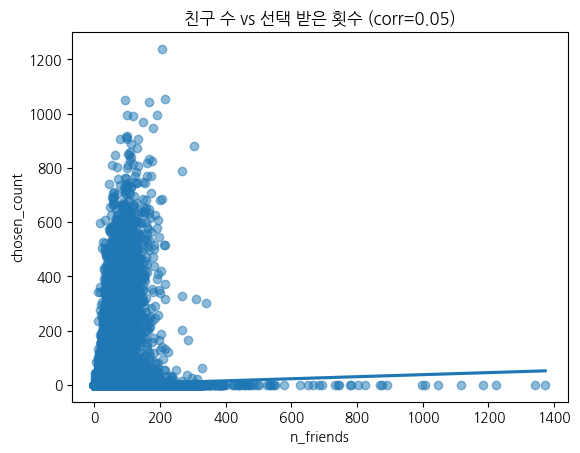

In [110]:
user_df["friend_id_list"] = user_df["friend_id_list"].apply(json.loads)
user_df["n_friends"] = user_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df["attendance_date_list"] = user_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)
user_df["n_attendance"] = user_df["attendance_date_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)


chosen_count = vote_point_df.groupby("chosen_user_id").size().reset_index(name="chosen_count")
vote_count = vote_point_df.groupby("user_id").size().reset_index(name="vote_count")

updated_user_df = (
    user_df
    .merge(chosen_count, left_on="user_id", right_on="chosen_user_id", how="left")
    .merge(vote_count, left_on="user_id", right_on="user_id", how="left")
)
updated_user_df[["chosen_count", "vote_count"]] = updated_user_df[["chosen_count", "vote_count"]].fillna(0)

corr_chosen = updated_user_df["n_friends"].corr(updated_user_df["chosen_count"])
sns.regplot(data=updated_user_df, x="n_friends", y="chosen_count", scatter_kws={'alpha':0.5})
plt.title(f"친구 수 vs 선택 받은 횟수 (corr={corr_chosen:.2f})")
plt.show()

2. 친구가 많을수록 투표 많이 하는가

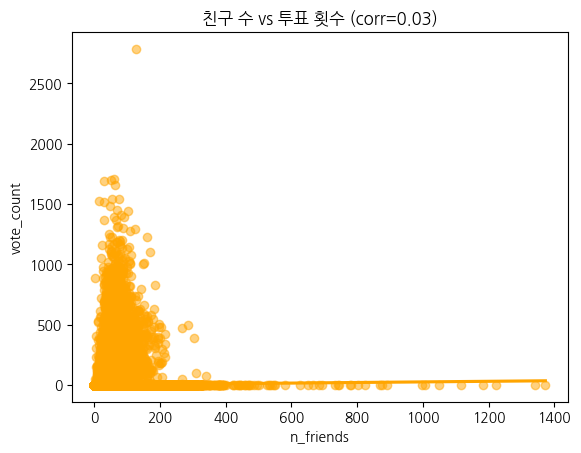

In [112]:
corr_vote = updated_user_df["n_friends"].corr(updated_user_df["vote_count"])
sns.regplot(data=updated_user_df, x="n_friends", y="vote_count", scatter_kws={'alpha':0.5}, color="orange")
plt.title(f"친구 수 vs 투표 횟수 (corr={corr_vote:.2f})")
plt.show()

3. 출석일수가 높을수록 포인트 보유량이 많은가

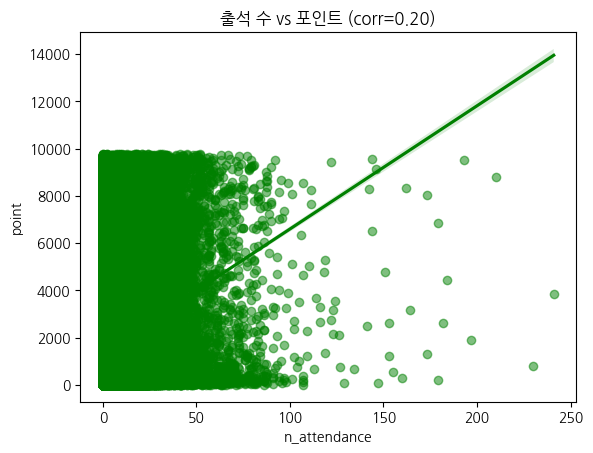

In [115]:
updated_user_df = updated_user_df[updated_user_df["point"] < updated_user_df["point"].quantile(0.99)]

corr_point = updated_user_df["n_attendance"].corr(updated_user_df["point"])
sns.regplot(data=updated_user_df, x="n_attendance", y="point", scatter_kws={'alpha':0.5}, color="green")
plt.title(f"출석 수 vs 포인트 (corr={corr_point:.2f})")
plt.show()

paymenthistory_df

1. 어느 유저가 구매를 많이 했는가

In [131]:
user_purchase = (
    paymenthistory_df.groupby("user_id").size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)
print("구매 많이 한 유저 TOP 10")
print(user_purchase.head(10))

구매 많이 한 유저 TOP 10
       user_id  purchase_count
55604  1527451              60
27744  1246471              51
17651  1141603              35
23067  1204373              34
17740  1142775              30
19921  1170271              27
14443  1099530              27
48412  1455819              25
38704  1358363              25
3839    925538              24


2. 어떤 상품이 많이 구매되었는가

In [121]:
product_purchase = (
    paymenthistory_df.groupby("productId").size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)
print("상품별 구매 건수")
print(product_purchase)


상품별 구매 건수
    productId  purchase_count
3   heart.777           57873
0  heart.1000           19309
1   heart.200           15822
2  heart.4000            2136


3. 언제/어느 시간대에 구매가 많이 이루어졌는가

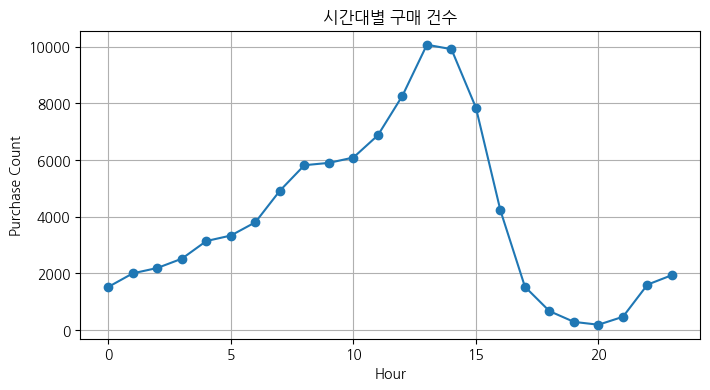

In [124]:
paymenthistory_df["created_at"] = pd.to_datetime(paymenthistory_df["created_at"])
paymenthistory_df["hour"] = paymenthistory_df["created_at"].dt.hour
paymenthistory_df["year_month"] = paymenthistory_df["created_at"].dt.to_period("M").astype(str)

hourly_purchase = paymenthistory_df.groupby("hour").size().reset_index(name="purchase_count")
monthly_purchase = paymenthistory_df.groupby("year_month").size().reset_index(name="purchase_count")

plt.figure(figsize=(8,4))
plt.plot(hourly_purchase["hour"], hourly_purchase["purchase_count"], marker="o")
plt.title("시간대별 구매 건수")
plt.xlabel("Hour")
plt.ylabel("Purchase Count")
plt.grid(True)
plt.show()


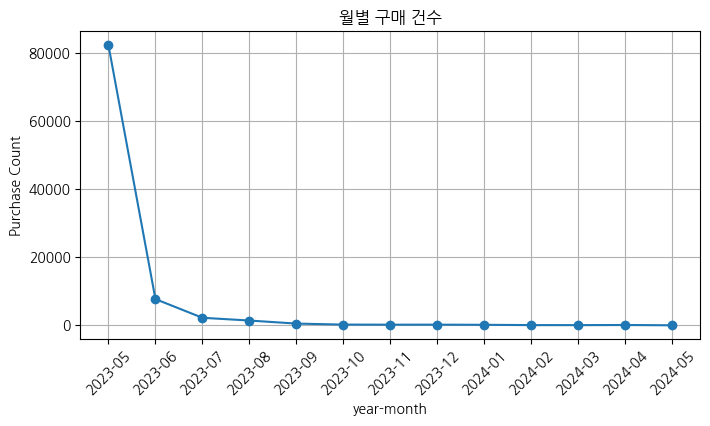

In [127]:
plt.figure(figsize=(8,4))
plt.plot(monthly_purchase["year_month"], monthly_purchase["purchase_count"], marker="o")
plt.title("월별 구매 건수")
plt.xlabel("year-month")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

4. 상품 구매를 많이 한 유저가 포인트 사용량이 많은가

구매 횟수 vs 선택받은 횟수 상관계수: -0.00


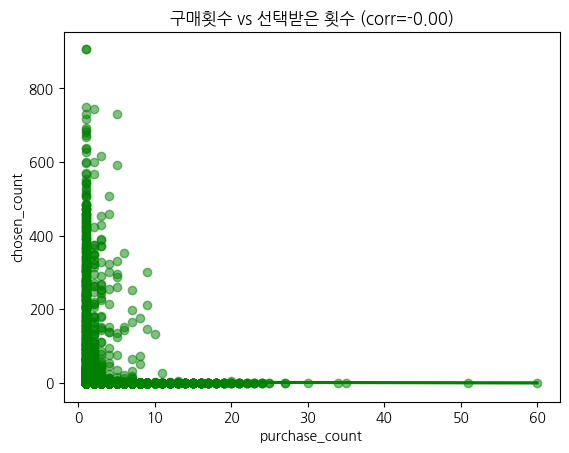

In [141]:
chosen_count = vote_point_df.groupby("chosen_user_id").size().reset_index(name="chosen_count")
user_summary = user_purchase.merge(chosen_count, left_on="user_id", right_on="chosen_user_id", how="left").fillna(0)

corr_purchase_chosen = user_summary["purchase_count"].corr(user_summary["chosen_count"])
print(f"구매 횟수 vs 선택받은 횟수 상관계수: {corr_purchase_chosen:.2f}")

sns.regplot(data=user_summary, x="purchase_count", y="chosen_count", scatter_kws={'alpha':0.5}, color="green")
plt.title(f"구매횟수 vs 선택받은 횟수 (corr={corr_purchase_chosen:.2f})")
plt.show()